In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, chi2
import warnings
warnings.filterwarnings('ignore')

# Configuration pour les graphiques en français
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

# Chargement des données
print("Chargement des données...")
df = pd.read_csv('assets/caract-2023.csv', sep=';', encoding='utf-8')
print(f"Données chargées : {len(df)} enregistrements")
print(f"\nColonnes : {df.columns.tolist()}")
print(f"\nPremières lignes :")
print(df.head())


Chargement des données...
Données chargées : 54822 enregistrements

Colonnes : ['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg', 'int', 'atm', 'col', 'adr', 'lat', 'long']

Premières lignes :
        Num_Acc  jour  mois    an   hrmn  lum dep    com  agg  int  atm  col  \
0  202300000001     7     5  2023  06:00    1  75  75101    2    4    2    7   
1  202300000002     7     5  2023  05:30    5  94  94080    2    1    3    6   
2  202300000003     7     5  2023  20:50    1  94  94022    2    3    2    1   
3  202300000004     6     5  2023  23:57    5  94  94078    2    1    3    5   
4  202300000005     7     5  2023  00:50    5  94  94068    2    2    3    3   

                         adr          lat        long  
0              RUE DE RIVOLI  48,86638600  2,32347100  
1            Avenue de Paris  48,84547782  2,42868146  
2  Avenue du Général Leclerc  48,76240000  2,40655000  
3               Rue de Paris  48,73248432  2,44687575  
4       56bis Avenue Raspai

In [2]:
# ============================================================================
# PRÉPARATION DES DONNÉES - CRÉATION DES VARIABLES DATETIME ET DÉPARTEMENT
# ============================================================================

# Conversion des colonnes de date au format datetime
df['date'] = pd.to_datetime(df['an'].astype(str) + '-' + 
                            df['mois'].astype(str).str.zfill(2) + '-' + 
                            df['jour'].astype(str).str.zfill(2), 
                            format='%Y-%m-%d', errors='coerce')

# Extraction des caractéristiques temporelles
df['jour_semaine'] = df['date'].dt.day_name()
df['jour_semaine_num'] = df['date'].dt.dayofweek  # 0=Lundi, 6=Dimanche
df['mois_annee'] = df['mois'].astype(int)
df['semaine_annee'] = df['date'].dt.isocalendar().week

# Traduction des jours de la semaine en français
jours_fr = {
    'Monday': 'Lundi',
    'Tuesday': 'Mardi',
    'Wednesday': 'Mercredi',
    'Thursday': 'Jeudi',
    'Friday': 'Vendredi',
    'Saturday': 'Samedi',
    'Sunday': 'Dimanche'
}
df['jour_semaine_fr'] = df['jour_semaine'].map(jours_fr)

# Traduction des mois en français
mois_fr = {
    1: 'Janvier', 2: 'Février', 3: 'Mars', 4: 'Avril',
    5: 'Mai', 6: 'Juin', 7: 'Juillet', 8: 'Août',
    9: 'Septembre', 10: 'Octobre', 11: 'Novembre', 12: 'Décembre'
}
df['mois_nom'] = df['mois_annee'].map(mois_fr)

# Parsing de l'heure
df['heure'] = pd.to_datetime(df['hrmn'], format='%H:%M', errors='coerce').dt.hour
df['minute'] = pd.to_datetime(df['hrmn'], format='%H:%M', errors='coerce').dt.minute

# Création de périodes de la journée
df['periode_journee'] = pd.cut(df['heure'], 
                               bins=[0, 6, 12, 18, 24], 
                               labels=['Nuit (0-6h)', 'Matin (6-12h)', 'Après-midi (12-18h)', 'Soirée (18-24h)'],
                               include_lowest=True)

# Nettoyage du code département
df['dep'] = df['dep'].astype(str).str.strip()

# Filtrage des données valides
df_clean = df.dropna(subset=['date', 'dep', 'heure']).copy()

print(f"Enregistrements après nettoyage : {len(df_clean)}")
print(f"Nombre de départements uniques : {df_clean['dep'].nunique()}")
print(f"\nVérification des valeurs manquantes :")
print(df_clean[['date', 'dep', 'heure', 'jour_semaine_fr', 'mois_nom']].isnull().sum())


Enregistrements après nettoyage : 54822
Nombre de départements uniques : 107

Vérification des valeurs manquantes :
date               0
dep                0
heure              0
jour_semaine_fr    0
mois_nom           0
dtype: int64


In [3]:
# ============================================================================
# TESTS DU CHI-DEUX (CHI-SQUARED) POUR TESTER L'INDÉPENDANCE
# ============================================================================
# Le test du Chi-deux permet de tester l'hypothèse d'indépendance entre
# deux variables catégorielles :
# H0 : Les variables sont indépendantes
# H1 : Les variables sont dépendantes (il existe une association)

print("="*80)
print("TESTS DU CHI-DEUX POUR L'INDÉPENDANCE : DÉPARTEMENT vs VARIABLES TEMPORELLES")
print("="*80)

def chi2_test_independence(df, var1, var2, alpha=0.05):
    """
    Effectue un test du Chi-deux pour tester l'indépendance entre deux variables catégorielles
    
    Parameters:
    -----------
    df : DataFrame
        DataFrame contenant les données
    var1 : str
        Nom de la première variable catégorielle
    var2 : str
        Nom de la deuxième variable catégorielle
    alpha : float
        Niveau de significativité (par défaut 0.05)
    
    Returns:
    --------
    dict : Dictionnaire contenant les résultats du test
    """
    # Création du tableau de contingence
    contingency_table = pd.crosstab(df[var1], df[var2])
    
    # Vérification des effectifs attendus (doivent être >= 5 pour au moins 80% des cellules)
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # Calcul du pourcentage de cellules avec effectifs attendus < 5
    pct_low_expected = (expected < 5).sum() / expected.size * 100
    
    # Interprétation
    is_independent = p_value > alpha
    interpretation = "Indépendantes" if is_independent else "Dépendantes (association significative)"
    
    # Calcul de Cramér's V pour mesurer la force de l'association
    n = contingency_table.sum().sum()
    cramers_v = np.sqrt(chi2_stat / (n * (min(contingency_table.shape) - 1)))
    
    # Interprétation de Cramér's V
    if cramers_v < 0.1:
        strength = "Négligeable"
    elif cramers_v < 0.3:
        strength = "Faible"
    elif cramers_v < 0.5:
        strength = "Modérée"
    else:
        strength = "Forte"
    
    return {
        'contingency_table': contingency_table,
        'chi2_statistic': chi2_stat,
        'p_value': p_value,
        'degrees_of_freedom': dof,
        'expected_frequencies': expected,
        'pct_low_expected': pct_low_expected,
        'is_independent': is_independent,
        'interpretation': interpretation,
        'cramers_v': cramers_v,
        'association_strength': strength
    }

# Test 1 : Département vs Mois
print("\n" + "="*80)
print("TEST 1 : DÉPARTEMENT vs MOIS")
print("="*80)
result_mois = chi2_test_independence(df_clean, 'dep', 'mois_nom')
print(f"Statistique Chi-deux : {result_mois['chi2_statistic']:.2f}")
print(f"Degrés de liberté : {result_mois['degrees_of_freedom']}")
print(f"P-value : {result_mois['p_value']:.2e}")
print(f"Interprétation : {result_mois['interpretation']} (α = 0.05)")
print(f"Cramér's V : {result_mois['cramers_v']:.4f} (Association {result_mois['association_strength'].lower()})")
print(f"Pourcentage de cellules avec effectifs attendus < 5 : {result_mois['pct_low_expected']:.2f}%")
if result_mois['pct_low_expected'] > 20:
    print("⚠️  ATTENTION : Plus de 20% des cellules ont des effectifs attendus < 5. Les résultats peuvent être peu fiables.")

# Test 2 : Département vs Jour de la semaine
print("\n" + "="*80)
print("TEST 2 : DÉPARTEMENT vs JOUR DE LA SEMAINE")
print("="*80)
result_jour = chi2_test_independence(df_clean, 'dep', 'jour_semaine_fr')
print(f"Statistique Chi-deux : {result_jour['chi2_statistic']:.2f}")
print(f"Degrés de liberté : {result_jour['degrees_of_freedom']}")
print(f"P-value : {result_jour['p_value']:.2e}")
print(f"Interprétation : {result_jour['interpretation']} (α = 0.05)")
print(f"Cramér's V : {result_jour['cramers_v']:.4f} (Association {result_jour['association_strength'].lower()})")
print(f"Pourcentage de cellules avec effectifs attendus < 5 : {result_jour['pct_low_expected']:.2f}%")
if result_jour['pct_low_expected'] > 20:
    print("⚠️  ATTENTION : Plus de 20% des cellules ont des effectifs attendus < 5. Les résultats peuvent être peu fiables.")

# Test 3 : Département vs Période de la journée
print("\n" + "="*80)
print("TEST 3 : DÉPARTEMENT vs PÉRIODE DE LA JOURNÉE")
print("="*80)
result_periode = chi2_test_independence(df_clean, 'dep', 'periode_journee')
print(f"Statistique Chi-deux : {result_periode['chi2_statistic']:.2f}")
print(f"Degrés de liberté : {result_periode['degrees_of_freedom']}")
print(f"P-value : {result_periode['p_value']:.2e}")
print(f"Interprétation : {result_periode['interpretation']} (α = 0.05)")
print(f"Cramér's V : {result_periode['cramers_v']:.4f} (Association {result_periode['association_strength'].lower()})")
print(f"Pourcentage de cellules avec effectifs attendus < 5 : {result_periode['pct_low_expected']:.2f}%")
if result_periode['pct_low_expected'] > 20:
    print("⚠️  ATTENTION : Plus de 20% des cellules ont des effectifs attendus < 5. Les résultats peuvent être peu fiables.")

# Test 4 : Département vs Heure (traitée comme catégorielle)
print("\n" + "="*80)
print("TEST 4 : DÉPARTEMENT vs HEURE (catégorielle)")
print("="*80)
result_heure = chi2_test_independence(df_clean, 'dep', 'heure')
print(f"Statistique Chi-deux : {result_heure['chi2_statistic']:.2f}")
print(f"Degrés de liberté : {result_heure['degrees_of_freedom']}")
print(f"P-value : {result_heure['p_value']:.2e}")
print(f"Interprétation : {result_heure['interpretation']} (α = 0.05)")
print(f"Cramér's V : {result_heure['cramers_v']:.4f} (Association {result_heure['association_strength'].lower()})")
print(f"Pourcentage de cellules avec effectifs attendus < 5 : {result_heure['pct_low_expected']:.2f}%")
if result_heure['pct_low_expected'] > 20:
    print("⚠️  ATTENTION : Plus de 20% des cellules ont des effectifs attendus < 5. Les résultats peuvent être peu fiables.")

# Résumé des tests
print("\n" + "="*80)
print("RÉSUMÉ DES TESTS DU CHI-DEUX")
print("="*80)
summary_df = pd.DataFrame({
    'Variable temporelle': ['Mois', 'Jour de la semaine', 'Période de la journée', 'Heure'],
    'Chi-deux': [result_mois['chi2_statistic'], result_jour['chi2_statistic'], 
                 result_periode['chi2_statistic'], result_heure['chi2_statistic']],
    'P-value': [result_mois['p_value'], result_jour['p_value'], 
                result_periode['p_value'], result_heure['p_value']],
    'Cramér\'s V': [result_mois['cramers_v'], result_jour['cramers_v'], 
                    result_periode['cramers_v'], result_heure['cramers_v']],
    'Association': [result_mois['association_strength'], result_jour['association_strength'],
                    result_periode['association_strength'], result_heure['association_strength']],
    'Indépendance (α=0.05)': [result_mois['interpretation'], result_jour['interpretation'],
                              result_periode['interpretation'], result_heure['interpretation']]
})
print(summary_df.to_string(index=False))
print("\n" + "="*80)


TESTS DU CHI-DEUX POUR L'INDÉPENDANCE : DÉPARTEMENT vs VARIABLES TEMPORELLES

TEST 1 : DÉPARTEMENT vs MOIS
Statistique Chi-deux : 1728.68
Degrés de liberté : 1166
P-value : 1.12e-24
Interprétation : Dépendantes (association significative) (α = 0.05)
Cramér's V : 0.0535 (Association négligeable)
Pourcentage de cellules avec effectifs attendus < 5 : 5.69%

TEST 2 : DÉPARTEMENT vs JOUR DE LA SEMAINE
Statistique Chi-deux : 1109.29
Degrés de liberté : 636
P-value : 3.35e-28
Interprétation : Dépendantes (association significative) (α = 0.05)
Cramér's V : 0.0581 (Association négligeable)
Pourcentage de cellules avec effectifs attendus < 5 : 4.01%

TEST 3 : DÉPARTEMENT vs PÉRIODE DE LA JOURNÉE
Statistique Chi-deux : 817.76
Degrés de liberté : 318
P-value : 1.00e-45
Interprétation : Dépendantes (association significative) (α = 0.05)
Cramér's V : 0.0705 (Association négligeable)
Pourcentage de cellules avec effectifs attendus < 5 : 3.50%

TEST 4 : DÉPARTEMENT vs HEURE (catégorielle)
Statistique 


Visualisation des résidus standardisés...


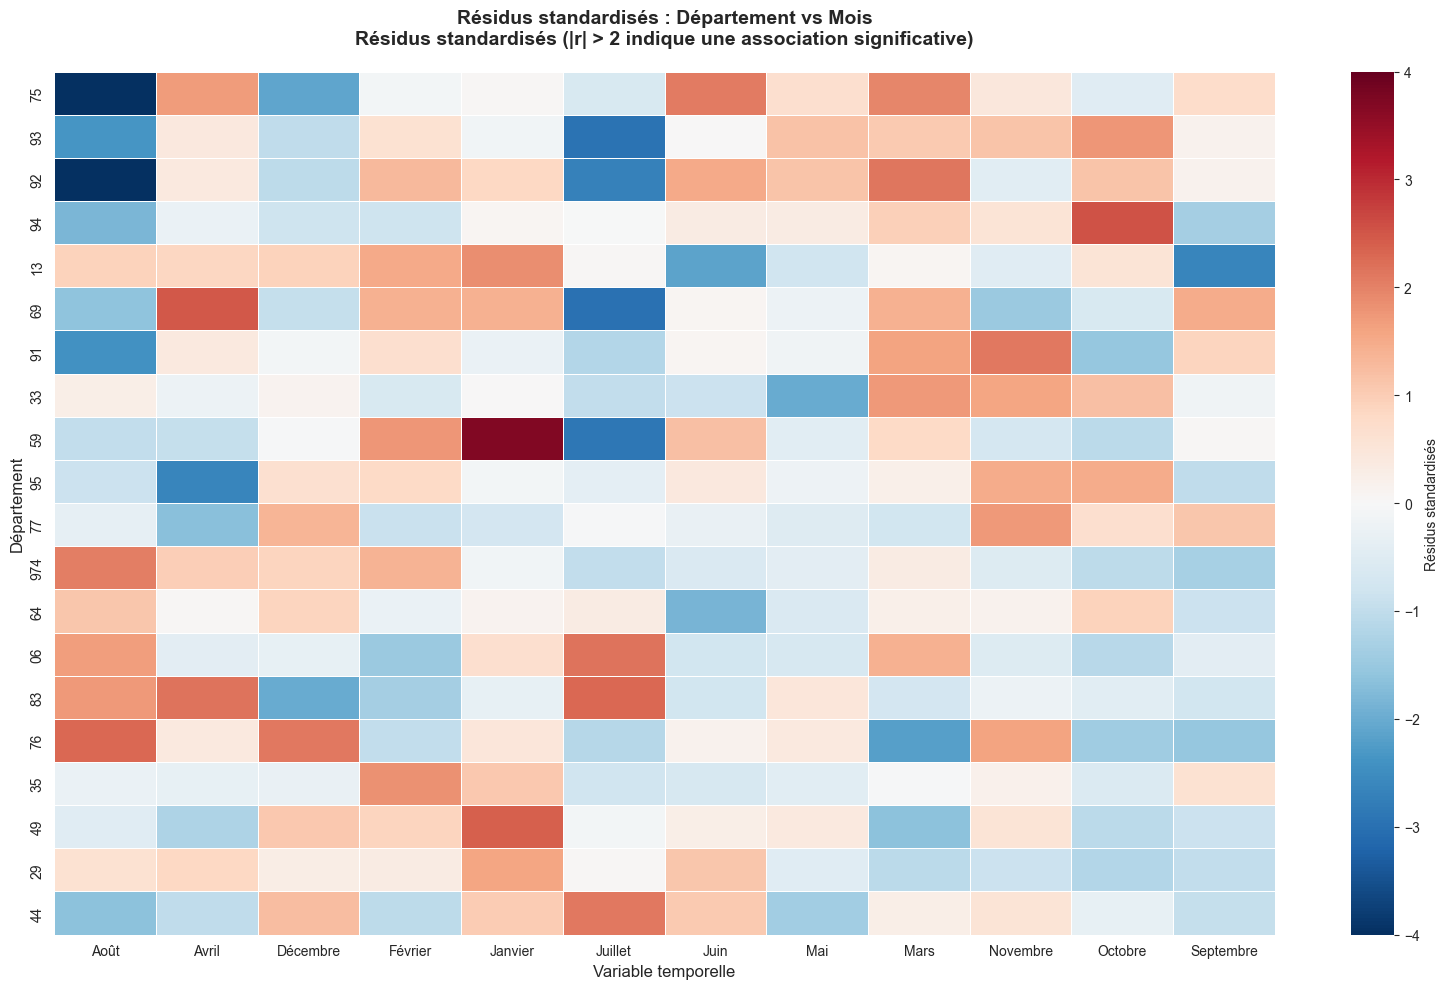

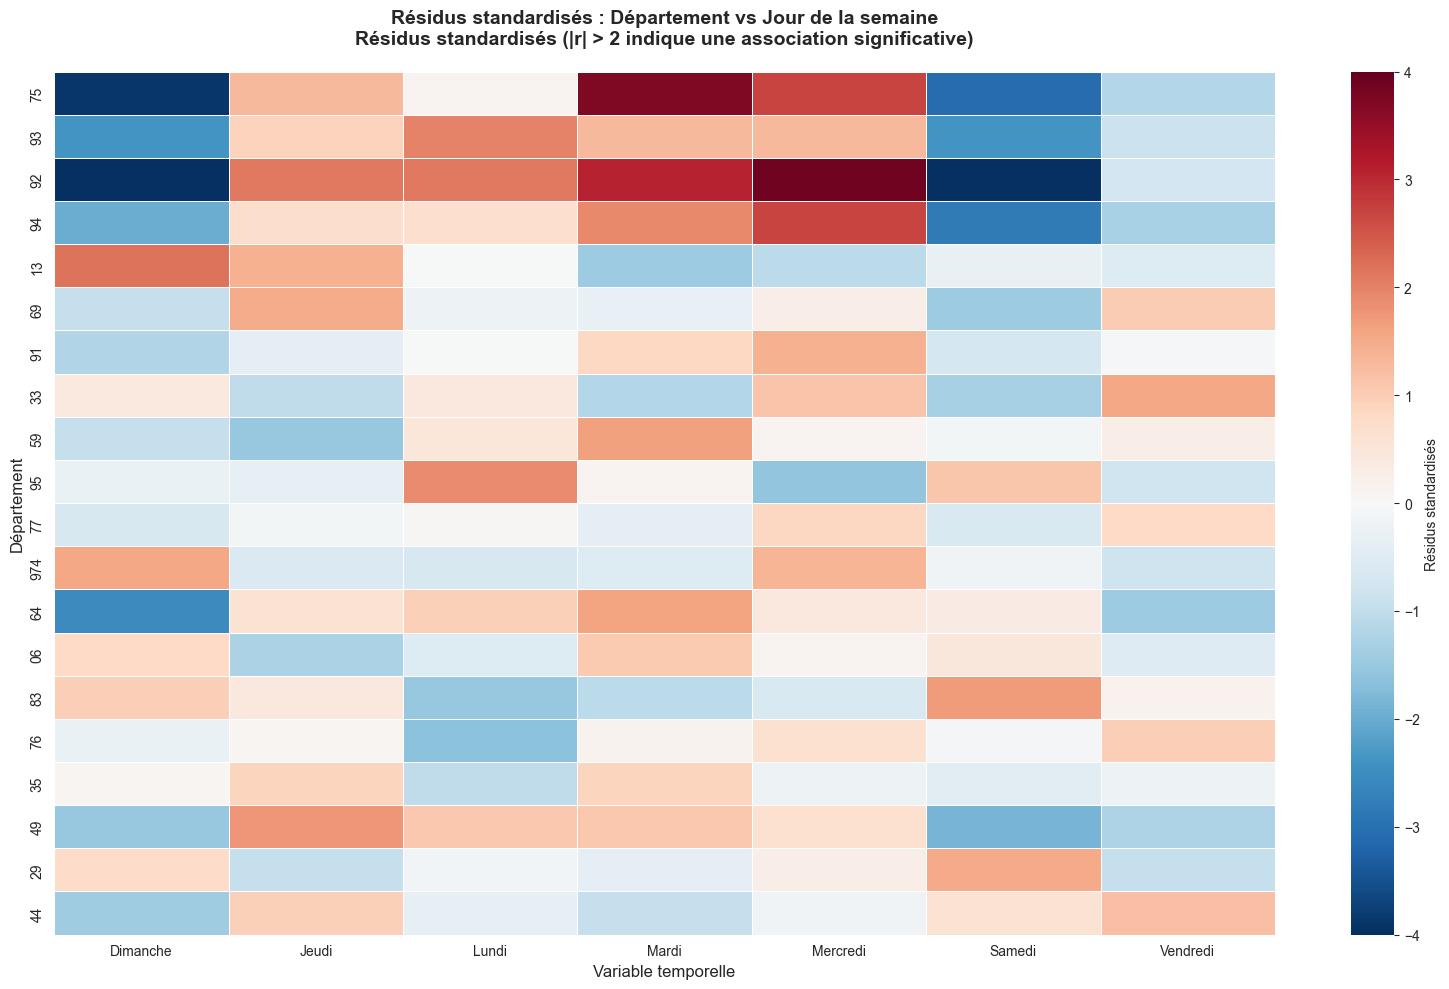

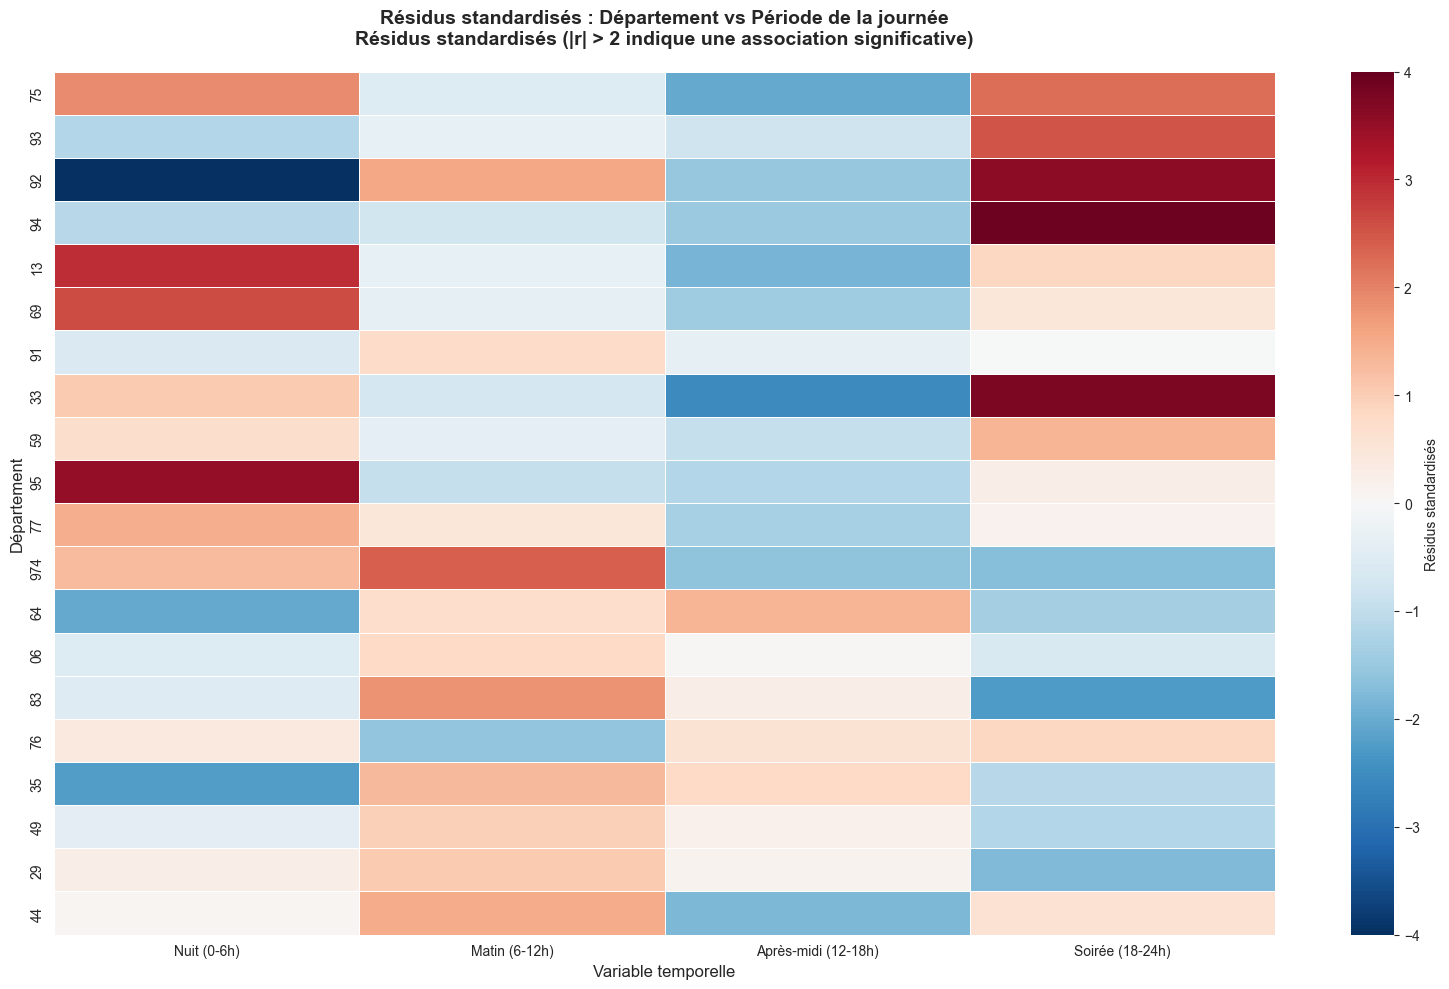

In [4]:
# ============================================================================
# VISUALISATION DES RÉSIDUS STANDARDISÉS DU CHI-DEUX
# ============================================================================
# Les résidus standardisés permettent d'identifier quelles combinaisons
# département-temps contribuent le plus à la dépendance observée

def plot_standardized_residuals(result, title, top_departments=20):
    """
    Visualise les résidus standardisés du test Chi-deux
    
    Les résidus standardisés > |2| indiquent des associations significatives
    """
    contingency = result['contingency_table']
    expected = result['expected_frequencies']
    
    # Calcul des résidus standardisés
    standardized_residuals = (contingency - expected) / np.sqrt(expected)
    
    # Sélection des top départements
    if top_departments:
        top_dep = contingency.sum(axis=1).nlargest(top_departments).index
        standardized_residuals = standardized_residuals.loc[top_dep]
    
    # Création du graphique
    plt.figure(figsize=(16, 10))
    sns.heatmap(standardized_residuals, annot=False, cmap='RdBu_r', center=0,
                cbar_kws={'label': 'Résidus standardisés'},
                vmin=-4, vmax=4, linewidths=0.5)
    plt.title(f'{title}\nRésidus standardisés (|r| > 2 indique une association significative)', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Variable temporelle', fontsize=12)
    plt.ylabel('Département', fontsize=12)
    plt.tight_layout()
    plt.show()

# Visualisation des résidus pour chaque test
print("\nVisualisation des résidus standardisés...")
plot_standardized_residuals(result_mois, 'Résidus standardisés : Département vs Mois', top_departments=20)
plot_standardized_residuals(result_jour, 'Résidus standardisés : Département vs Jour de la semaine', top_departments=20)
plot_standardized_residuals(result_periode, 'Résidus standardisés : Département vs Période de la journée', top_departments=20)


Tableau croisé : Département x Mois (Top 20 départements)
mois_nom  Janvier  Février  Mars  Avril   Mai  Juin  Juillet  Août  Septembre  \
dep                                                                             
Total        4053     3682  3998   4162  4767  5452     4754  4121       5161   
75            353      318   384    394   428   519      400   271        464   
93            194      186   208    207   248   264      185   166        252   
92            201      189   216    200   240   279      182   130        244   
94            164      138   173    164   196   224      191   142        188   
13            175      156   151    167   168   174      179   166        157   
69            159      145   157    176   164   192      128   125        201   
91             95       95   112    104   113   132      102    75        134   
33             88       74   103     88    83   109       93    92        110   
59            106       82    80     68    83   112

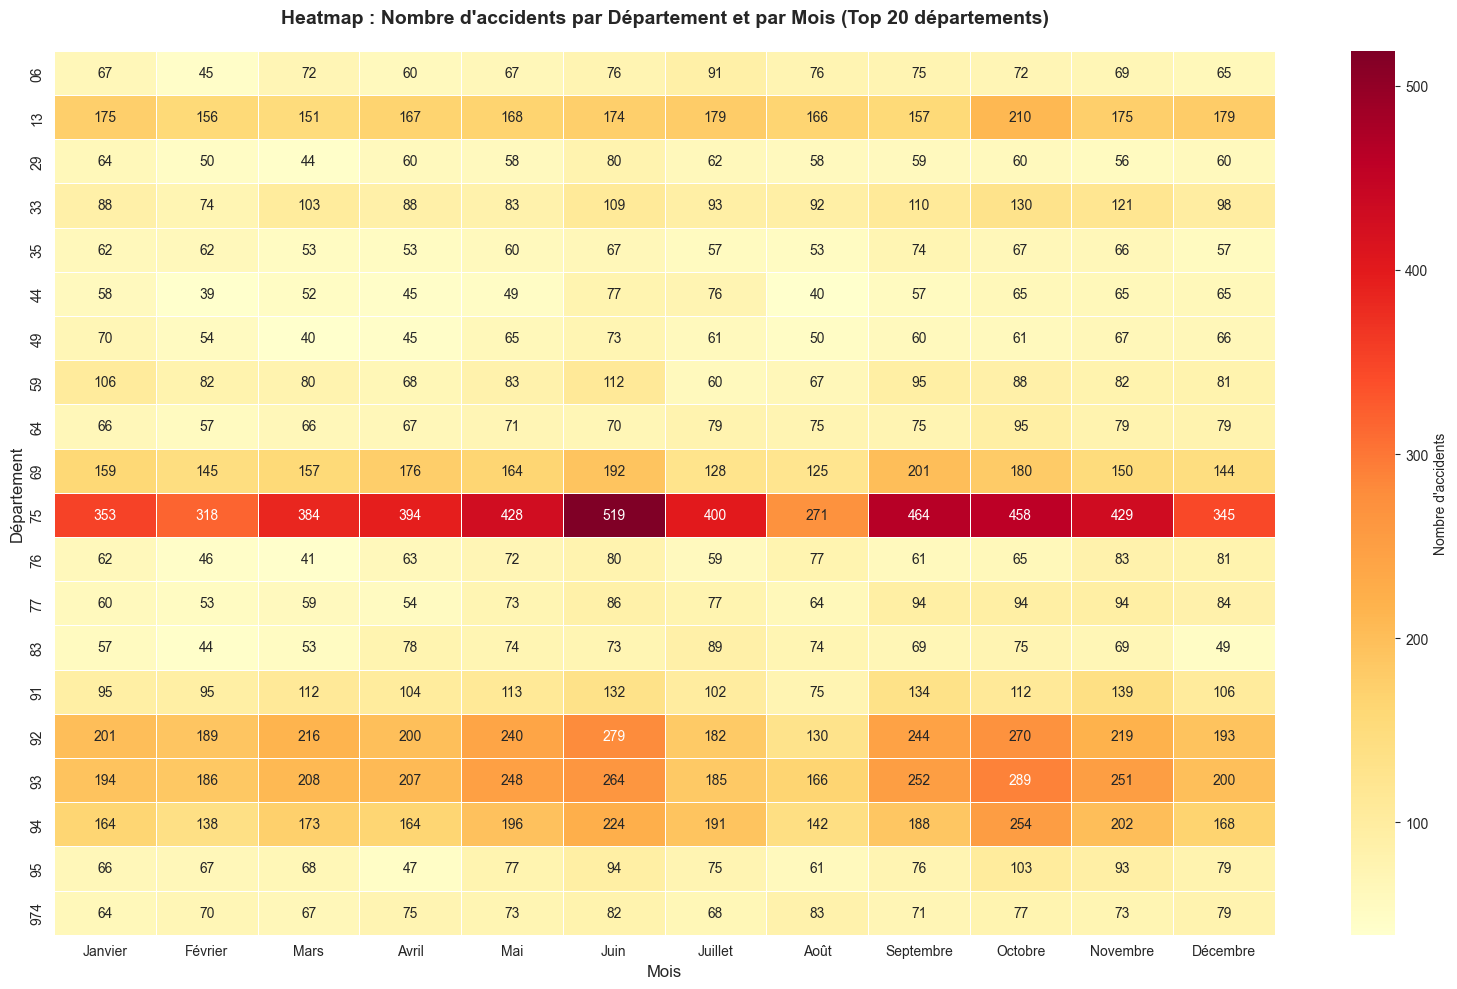

In [5]:
# ============================================================================
# ANALYSE BIVARIÉE 1 : ACCIDENTS PAR DÉPARTEMENT ET PAR MOIS
# ============================================================================

# Création d'un tableau croisé dynamique : Département x Mois
crosstab_mois = pd.crosstab(df_clean['dep'], df_clean['mois_nom'], 
                            margins=True, margins_name="Total")

# Réorganisation des colonnes par ordre chronologique
ordre_mois = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin',
              'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']
crosstab_mois = crosstab_mois[[m for m in ordre_mois if m in crosstab_mois.columns] + ['Total']]

print("Tableau croisé : Département x Mois (Top 20 départements)")
print("="*80)
print(crosstab_mois.sort_values('Total', ascending=False).head(20))

# Visualisation : Heatmap des accidents par département et par mois (Top 20 départements)
top_departements = df_clean['dep'].value_counts().head(20).index
df_top_dep = df_clean[df_clean['dep'].isin(top_departements)]

pivot_mois = pd.crosstab(df_top_dep['dep'], df_top_dep['mois_nom'])
pivot_mois = pivot_mois[[m for m in ordre_mois if m in pivot_mois.columns]]

plt.figure(figsize=(16, 10))
sns.heatmap(pivot_mois, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Nombre d\'accidents'}, linewidths=0.5)
plt.title('Heatmap : Nombre d\'accidents par Département et par Mois (Top 20 départements)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Mois', fontsize=12)
plt.ylabel('Département', fontsize=12)
plt.tight_layout()
plt.show()


Tableau croisé : Département x Jour de la semaine (Top 20 départements)
jour_semaine_fr  Lundi  Mardi  Mercredi  Jeudi  Vendredi  Samedi  Dimanche  \
dep                                                                          
Total             7279   8090      8117   8001      8873    7761      6701   
75                 635    802       777    729       738     594       488   
93                 389    417       418    405       411     329       281   
92                 379    438       455    415       400     263       213   
94                 304    360       375    334       332     262       237   
13                 273    278       286    325       323     286       286   
69                 252    278       289    305       329     248       220   
91                 175    206       215    187       213     177       146   
33                 163    160       191    160       214     151       150   
59                 139    168       150    128       166     141      

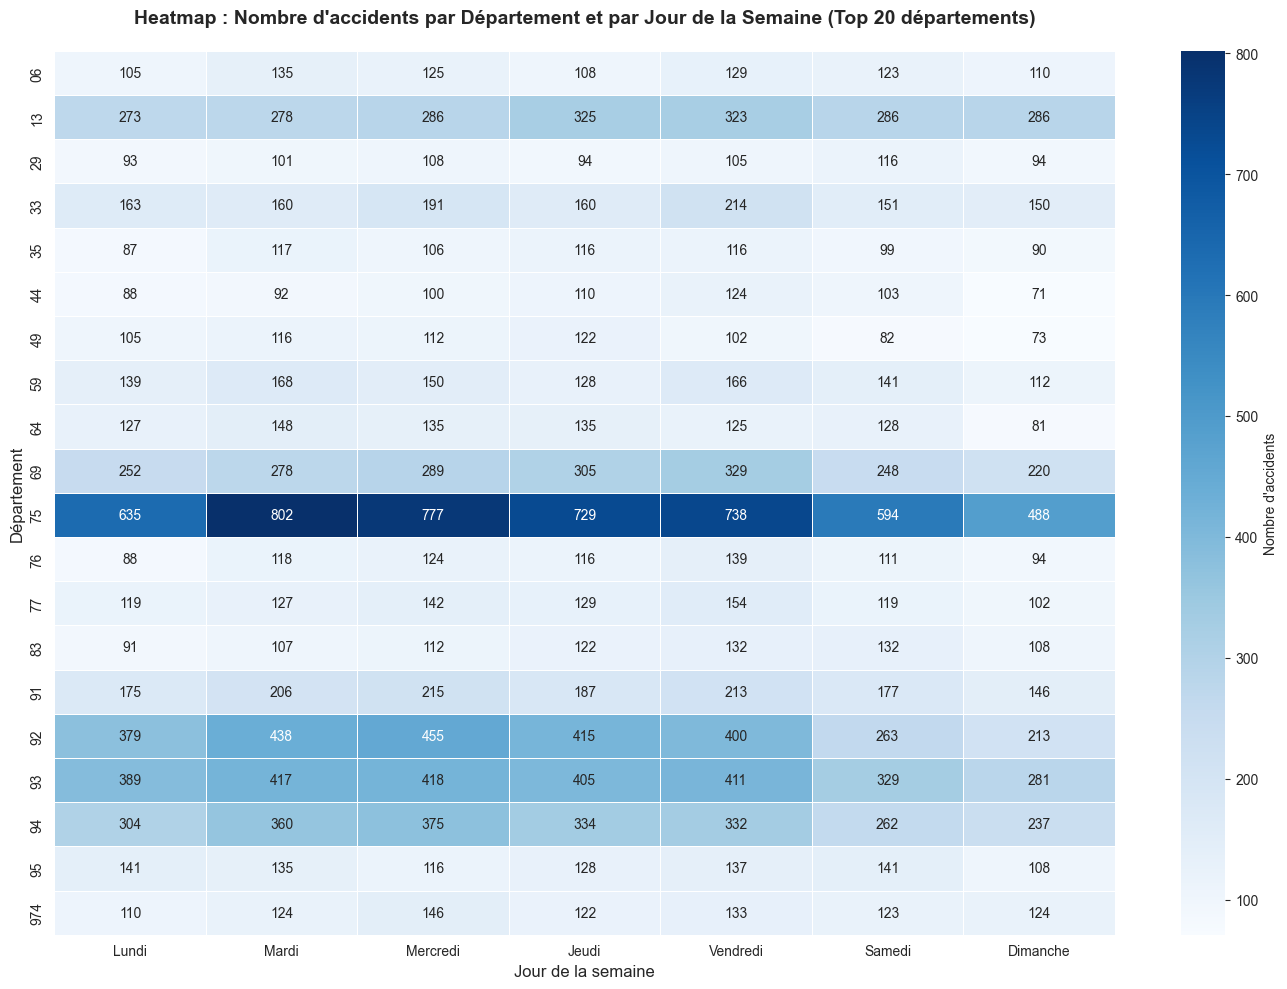

In [6]:
# ============================================================================
# ANALYSE BIVARIÉE 2 : ACCIDENTS PAR DÉPARTEMENT ET PAR JOUR DE LA SEMAINE
# ============================================================================

# Création d'un tableau croisé dynamique : Département x Jour de la semaine
ordre_jours = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
crosstab_jour = pd.crosstab(df_clean['dep'], df_clean['jour_semaine_fr'], 
                            margins=True, margins_name="Total")
crosstab_jour = crosstab_jour[[j for j in ordre_jours if j in crosstab_jour.columns] + ['Total']]

print("Tableau croisé : Département x Jour de la semaine (Top 20 départements)")
print("="*80)
print(crosstab_jour.sort_values('Total', ascending=False).head(20))

# Visualisation : Heatmap des accidents par département et par jour de la semaine
pivot_jour = pd.crosstab(df_top_dep['dep'], df_top_dep['jour_semaine_fr'])
pivot_jour = pivot_jour[[j for j in ordre_jours if j in pivot_jour.columns]]

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_jour, annot=True, fmt='d', cmap='Blues', 
            cbar_kws={'label': 'Nombre d\'accidents'}, linewidths=0.5)
plt.title('Heatmap : Nombre d\'accidents par Département et par Jour de la Semaine (Top 20 départements)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Jour de la semaine', fontsize=12)
plt.ylabel('Département', fontsize=12)
plt.tight_layout()
plt.show()


Tableau croisé : Département x Heure (Top 10 départements)
heure    0    1   2   3   4   5   6    7    8    9  ...   15   16   17   18  \
dep                                                 ...                       
75     136  102  82  57  49  58  80  137  268  312  ...  272  312  309  379   
93      55   38  34  27  24  38  54  110  180  174  ...  138  171  204  231   
92      37   38  32  24  19  17  40   92  160  177  ...  133  163  173  249   
94      42   31  36  25  20  26  44   99  141  135  ...  127  123  165  204   
13      51   39  35  30  31  32  51   96  124   98  ...  131  120  152  165   
69      51   38  22  31  31  30  45   84  112  102  ...  101  127  149  167   
91      26   18  20  11  12  20  30   67  101   81  ...   74   91  111  113   
33      23   28  22  14   5  12  38   67   80   53  ...   60   71   88  110   
59      17   20  15  14  16  20  15   59   73   37  ...   56   76   73   88   
95      17   25  11   9  24  20  28   37   63   52  ...   52   62   65  

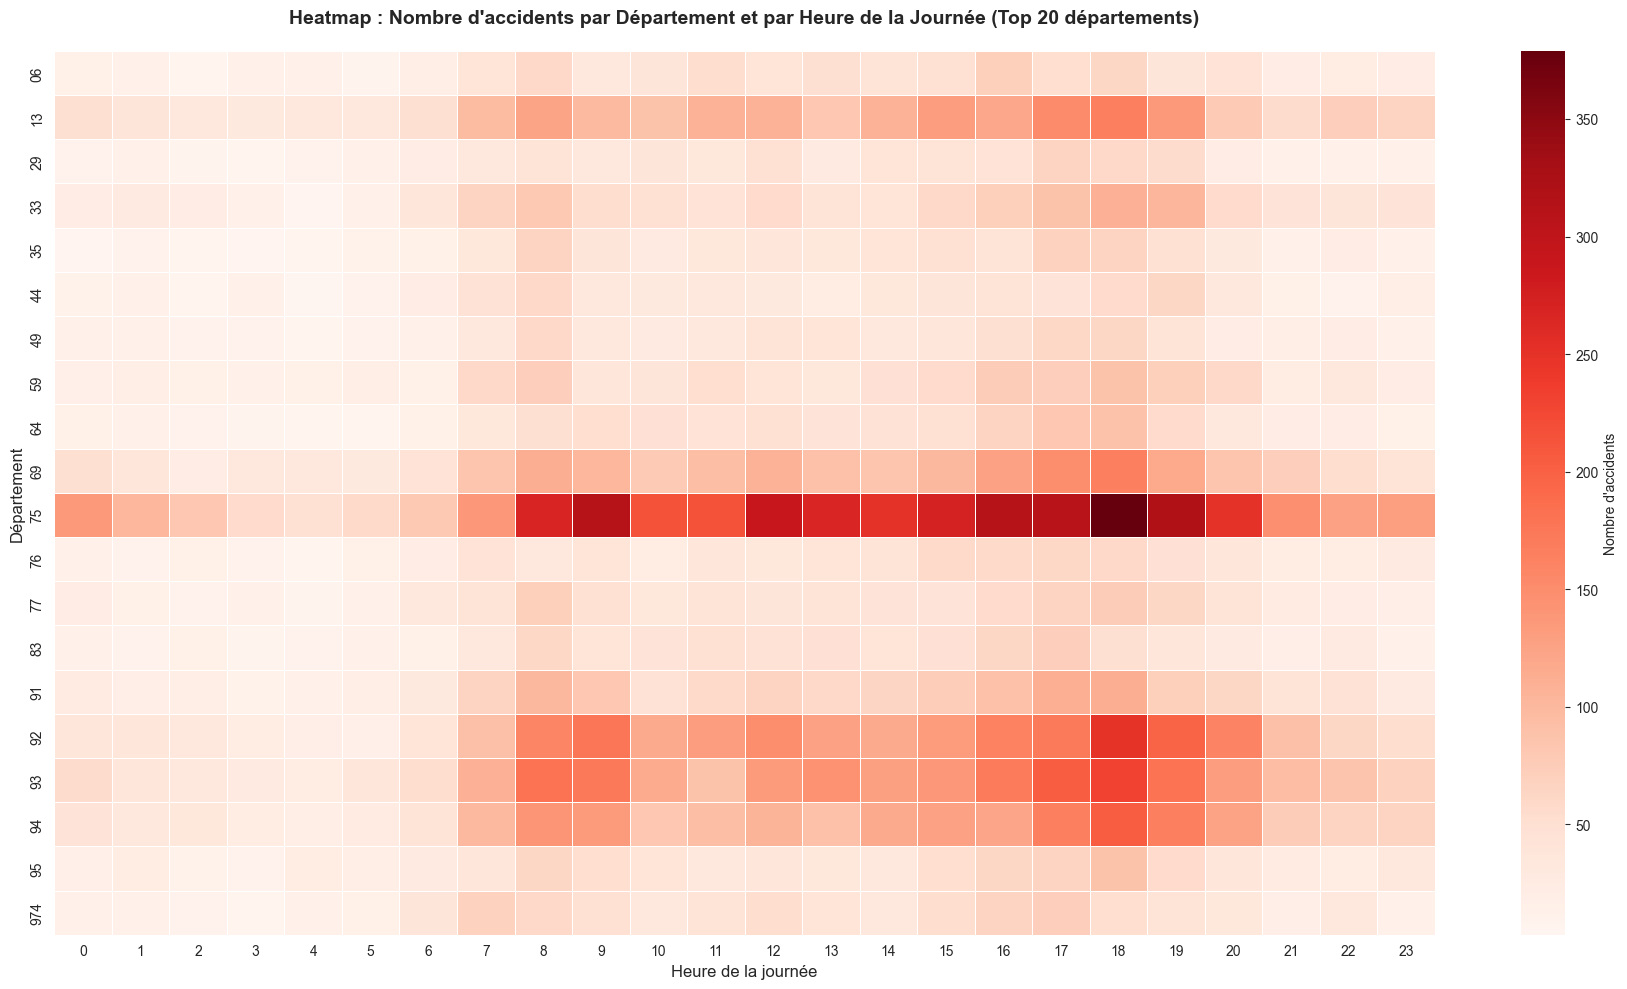

In [7]:
# ============================================================================
# ANALYSE BIVARIÉE 3 : ACCIDENTS PAR DÉPARTEMENT ET PAR HEURE DE LA JOURNÉE
# ============================================================================

# Création d'un tableau croisé dynamique : Département x Heure
crosstab_heure = pd.crosstab(df_clean['dep'], df_clean['heure'], 
                             margins=True, margins_name="Total")

print("Tableau croisé : Département x Heure (Top 10 départements)")
print("="*80)
top_10_dep = df_clean['dep'].value_counts().head(10).index
print(crosstab_heure.loc[top_10_dep].sort_values('Total', ascending=False))

# Visualisation : Heatmap des accidents par département et par heure (Top 20 départements)
pivot_heure = pd.crosstab(df_top_dep['dep'], df_top_dep['heure'])

plt.figure(figsize=(18, 10))
sns.heatmap(pivot_heure, annot=False, cmap='Reds', 
            cbar_kws={'label': 'Nombre d\'accidents'}, linewidths=0.5)
plt.title('Heatmap : Nombre d\'accidents par Département et par Heure de la Journée (Top 20 départements)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Heure de la journée', fontsize=12)
plt.ylabel('Département', fontsize=12)
plt.tight_layout()
plt.show()


Tableau croisé : Département x Période de la journée (Top 20 départements)
periode_journee  Nuit (0-6h)  Matin (6-12h)  Après-midi (12-18h)  \
dep                                                                
Total                   5995          16763                21624   
75                       564           1435                 1790   
93                       270            801                 1018   
92                       207            827                  962   
94                       224            654                  826   
13                       269            621                  758   
69                       248            579                  719   
91                       137            419                  512   
33                       142            350                  414   
59                       117            300                  377   
95                       134            261                  335   
77                       112            2

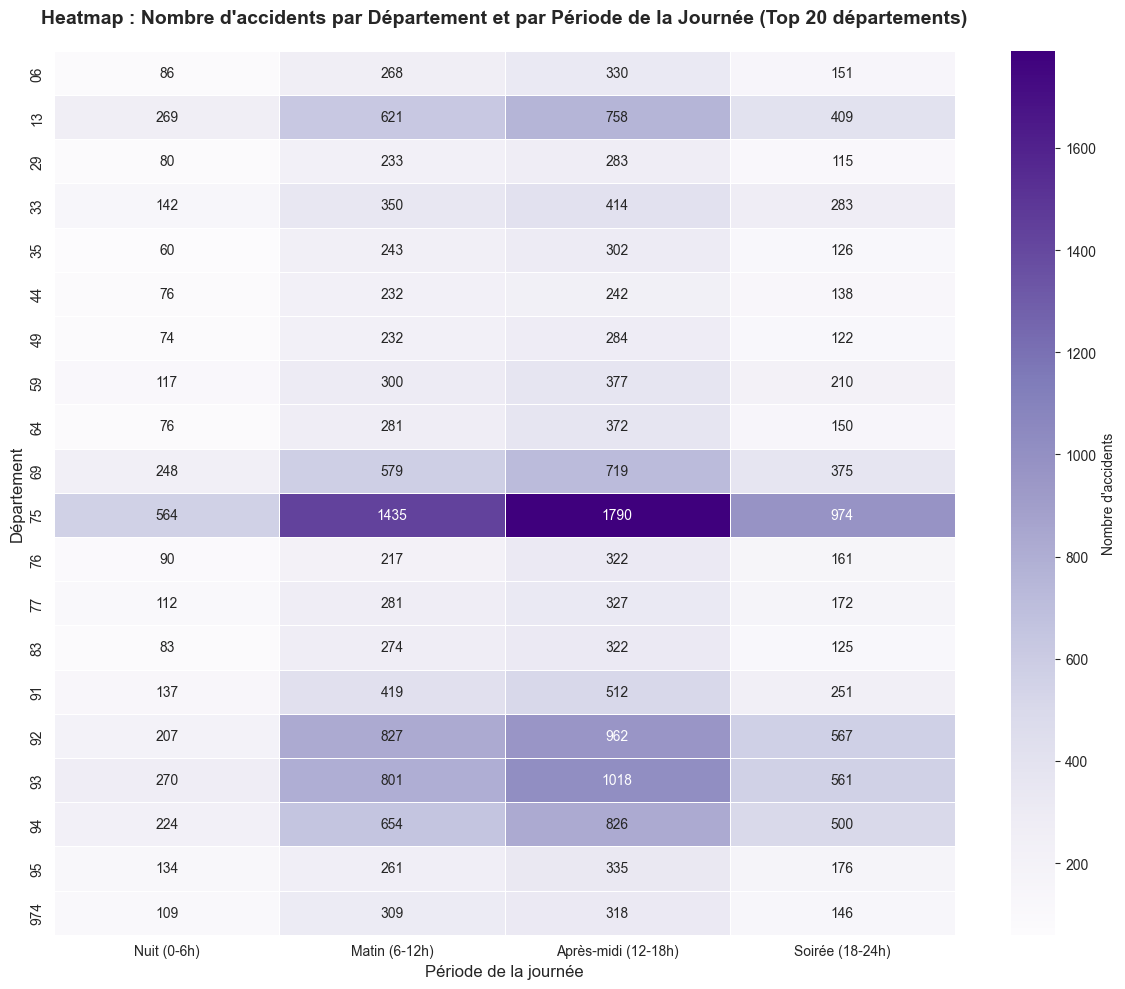

In [8]:
# ============================================================================
# ANALYSE BIVARIÉE 4 : ACCIDENTS PAR DÉPARTEMENT ET PAR PÉRIODE DE LA JOURNÉE
# ============================================================================

# Création d'un tableau croisé dynamique : Département x Période de la journée
ordre_periodes = ['Nuit (0-6h)', 'Matin (6-12h)', 'Après-midi (12-18h)', 'Soirée (18-24h)']
crosstab_periode = pd.crosstab(df_clean['dep'], df_clean['periode_journee'], 
                               margins=True, margins_name="Total")
crosstab_periode = crosstab_periode[[p for p in ordre_periodes if p in crosstab_periode.columns] + ['Total']]

print("Tableau croisé : Département x Période de la journée (Top 20 départements)")
print("="*80)
print(crosstab_periode.sort_values('Total', ascending=False).head(20))

# Visualisation : Heatmap des accidents par département et par période
pivot_periode = pd.crosstab(df_top_dep['dep'], df_top_dep['periode_journee'])
pivot_periode = pivot_periode[[p for p in ordre_periodes if p in pivot_periode.columns]]

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_periode, annot=True, fmt='d', cmap='Purples', 
            cbar_kws={'label': 'Nombre d\'accidents'}, linewidths=0.5)
plt.title('Heatmap : Nombre d\'accidents par Département et par Période de la Journée (Top 20 départements)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Période de la journée', fontsize=12)
plt.ylabel('Département', fontsize=12)
plt.tight_layout()
plt.show()


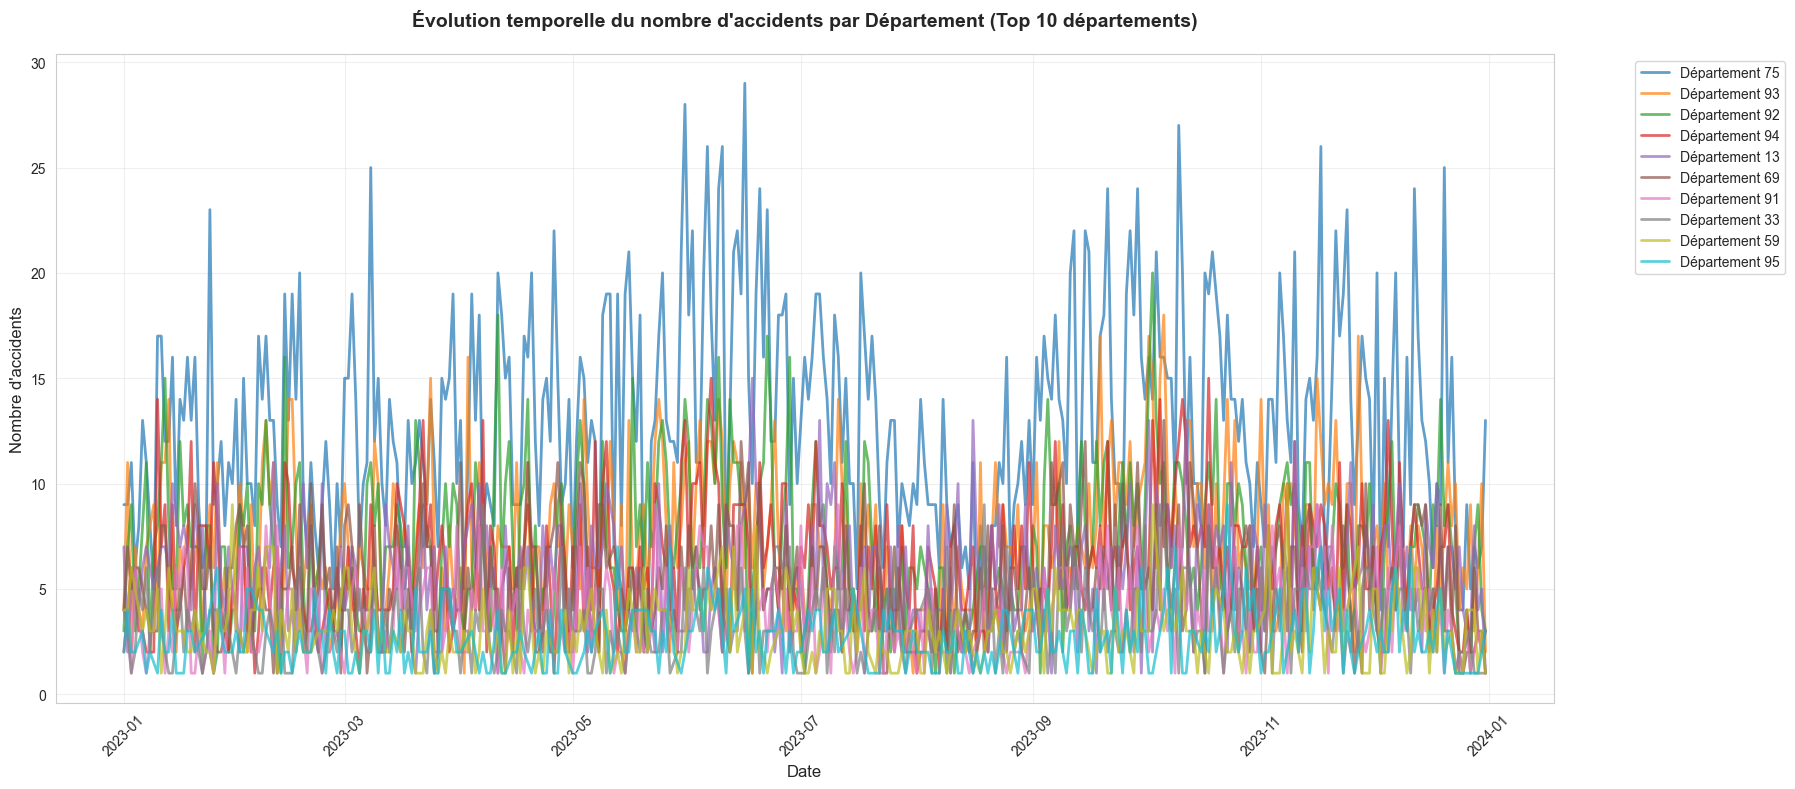

In [9]:
# ============================================================================
# ANALYSE BIVARIÉE 5 : SÉRIES TEMPORELLES PAR DÉPARTEMENT
# ============================================================================

# Agrégation par date et département
df_temporal = df_clean.groupby(['date', 'dep']).size().reset_index(name='nb_accidents')

# Sélection des 10 départements avec le plus d'accidents
top_10_dep_list = df_clean['dep'].value_counts().head(10).index.tolist()
df_temporal_top10 = df_temporal[df_temporal['dep'].isin(top_10_dep_list)]

# Visualisation : Série temporelle des accidents par département
fig, ax = plt.subplots(figsize=(18, 8))

for dep in top_10_dep_list:
    dep_data = df_temporal_top10[df_temporal_top10['dep'] == dep]
    ax.plot(dep_data['date'], dep_data['nb_accidents'], 
            label=f'Département {dep}', linewidth=2, alpha=0.7)

ax.set_title('Évolution temporelle du nombre d\'accidents par Département (Top 10 départements)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Nombre d\'accidents', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


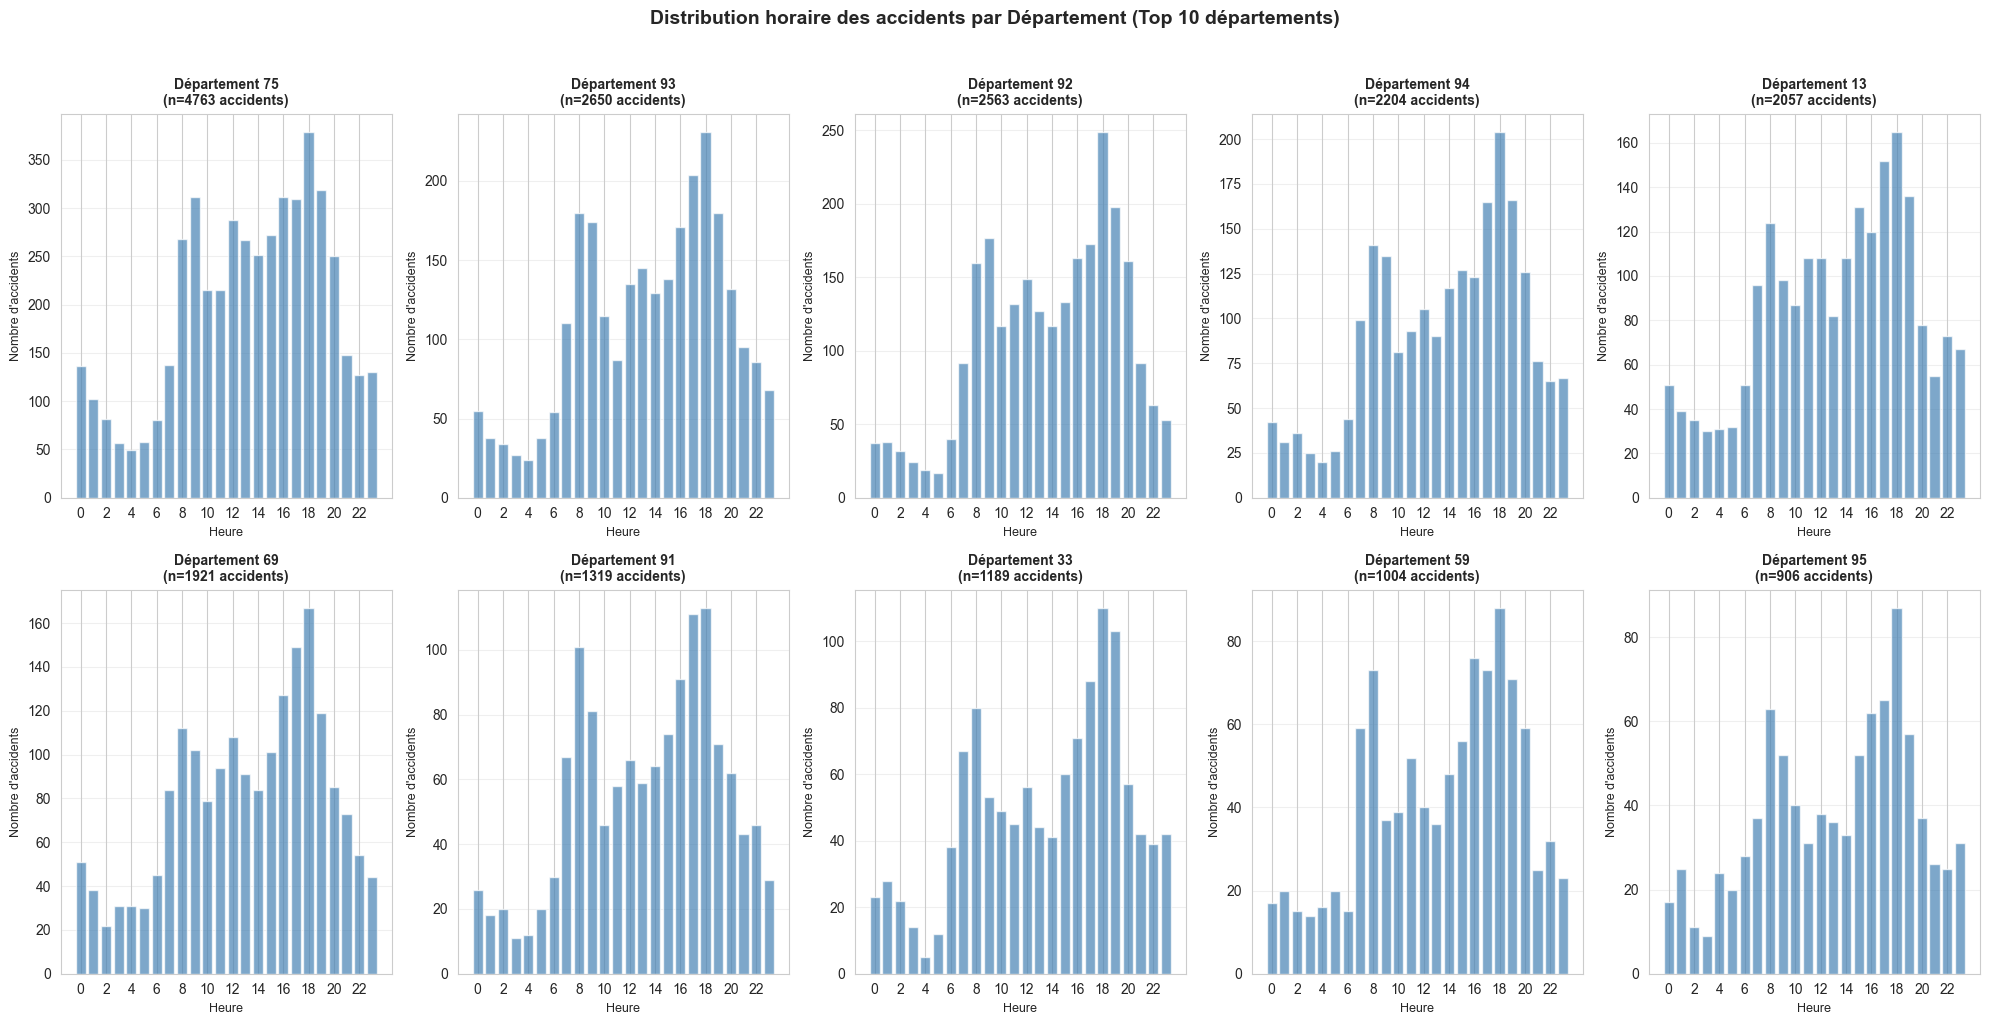

In [8]:
# ============================================================================
# ANALYSE BIVARIÉE 6 : PROFILS TEMPORELS PAR DÉPARTEMENT
# ============================================================================

# Création d'un graphique en barres groupées : Heure x Département (Top 10)
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, dep in enumerate(top_10_dep_list[:10]):
    dep_data = df_clean[df_clean['dep'] == dep]
    heure_counts = dep_data['heure'].value_counts().sort_index()
    
    axes[idx].bar(heure_counts.index, heure_counts.values, color='steelblue', alpha=0.7)
    axes[idx].set_title(f'Département {dep}\n(n={len(dep_data)} accidents)', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Heure', fontsize=9)
    axes[idx].set_ylabel('Nombre d\'accidents', fontsize=9)
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].set_xticks(range(0, 24, 2))

plt.suptitle('Distribution horaire des accidents par Département (Top 10 départements)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [9]:
# ============================================================================
# ANALYSE BIVARIÉE 7 : STATISTIQUES DESCRIPTIVES PAR DÉPARTEMENT ET TEMPS
# ============================================================================

# Calcul de statistiques agrégées
stats_dep = df_clean.groupby('dep').agg({
    'date': ['min', 'max', 'count'],
    'heure': ['mean', 'std', 'min', 'max'],
    'jour_semaine_num': lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan
}).round(2)

stats_dep.columns = ['Date_min', 'Date_max', 'Nb_accidents', 
                     'Heure_moyenne', 'Heure_ecart_type', 'Heure_min', 'Heure_max', 
                     'Jour_semaine_plus_frequent']

# Ajout du nom du jour le plus fréquent
def get_jour_name(num):
    jours_num = {0: 'Lundi', 1: 'Mardi', 2: 'Mercredi', 3: 'Jeudi', 
                 4: 'Vendredi', 5: 'Samedi', 6: 'Dimanche'}
    return jours_num.get(int(num), 'N/A')

stats_dep['Jour_plus_frequent'] = stats_dep['Jour_semaine_plus_frequent'].apply(get_jour_name)

print("Statistiques descriptives par Département (Top 20)")
print("="*100)
print(stats_dep.sort_values('Nb_accidents', ascending=False).head(20))


Statistiques descriptives par Département (Top 20)
      Date_min   Date_max  Nb_accidents  Heure_moyenne  Heure_ecart_type  \
dep                                                                        
75  2023-01-01 2023-12-31          4763          13.30              5.78   
93  2023-01-01 2023-12-31          2650          13.56              5.65   
92  2023-01-01 2023-12-31          2563          13.79              5.42   
94  2023-01-01 2023-12-31          2204          13.69              5.71   
13  2023-01-01 2023-12-31          2057          13.20              5.88   
69  2023-01-01 2023-12-31          1921          13.21              5.82   
91  2023-01-02 2023-12-30          1319          13.37              5.63   
33  2023-01-01 2023-12-31          1189          13.56              5.96   
59  2023-01-01 2023-12-31          1004          13.37              5.78   
95  2023-01-01 2023-12-31           906          13.10              5.97   
77  2023-01-01 2023-12-31           8

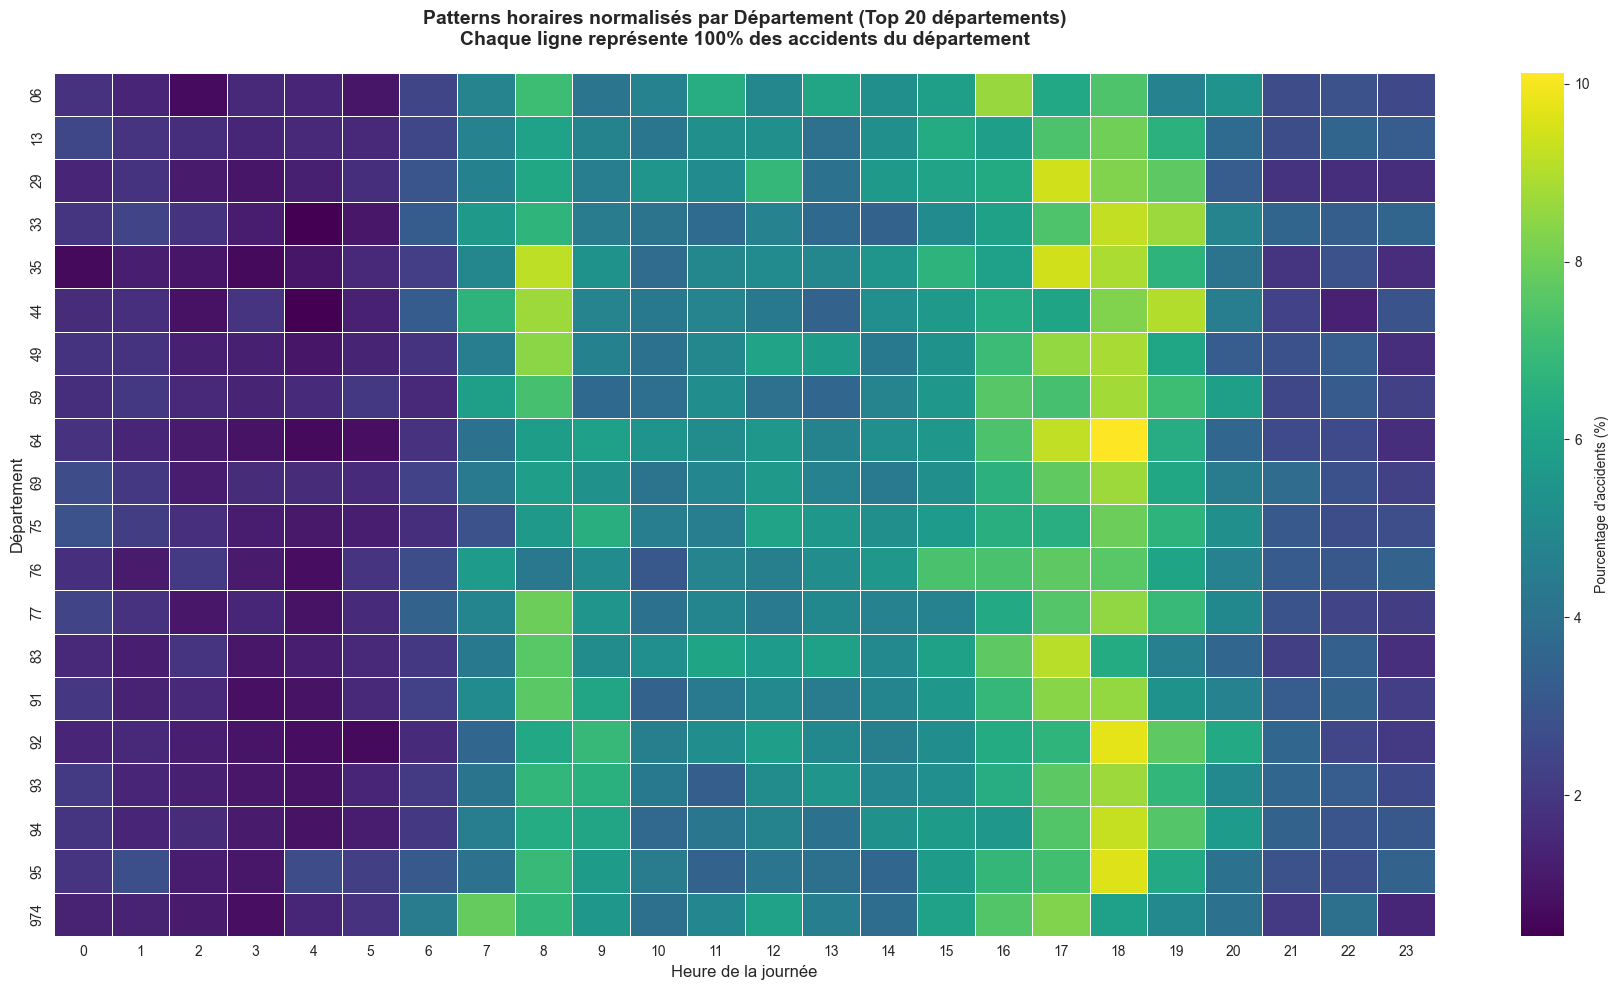

In [10]:
# ============================================================================
# ANALYSE BIVARIÉE 8 : COMPARAISON DES PATTERNS TEMPORELS ENTRE DÉPARTEMENTS
# ============================================================================

# Normalisation des données pour comparer les patterns (pourcentage par département)
def normalize_pattern(df_grouped, group_col, time_col):
    """Normalise les patterns temporels par département"""
    counts = pd.crosstab(df_grouped[group_col], df_grouped[time_col])
    return counts.div(counts.sum(axis=1), axis=0) * 100

# Normalisation par heure
pivot_heure_norm = normalize_pattern(df_top_dep, 'dep', 'heure')

# Visualisation : Patterns horaires normalisés
plt.figure(figsize=(18, 10))
sns.heatmap(pivot_heure_norm, annot=False, cmap='viridis', 
            cbar_kws={'label': 'Pourcentage d\'accidents (%)'}, linewidths=0.5)
plt.title('Patterns horaires normalisés par Département (Top 20 départements)\n' +
          'Chaque ligne représente 100% des accidents du département', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Heure de la journée', fontsize=12)
plt.ylabel('Département', fontsize=12)
plt.tight_layout()
plt.show()


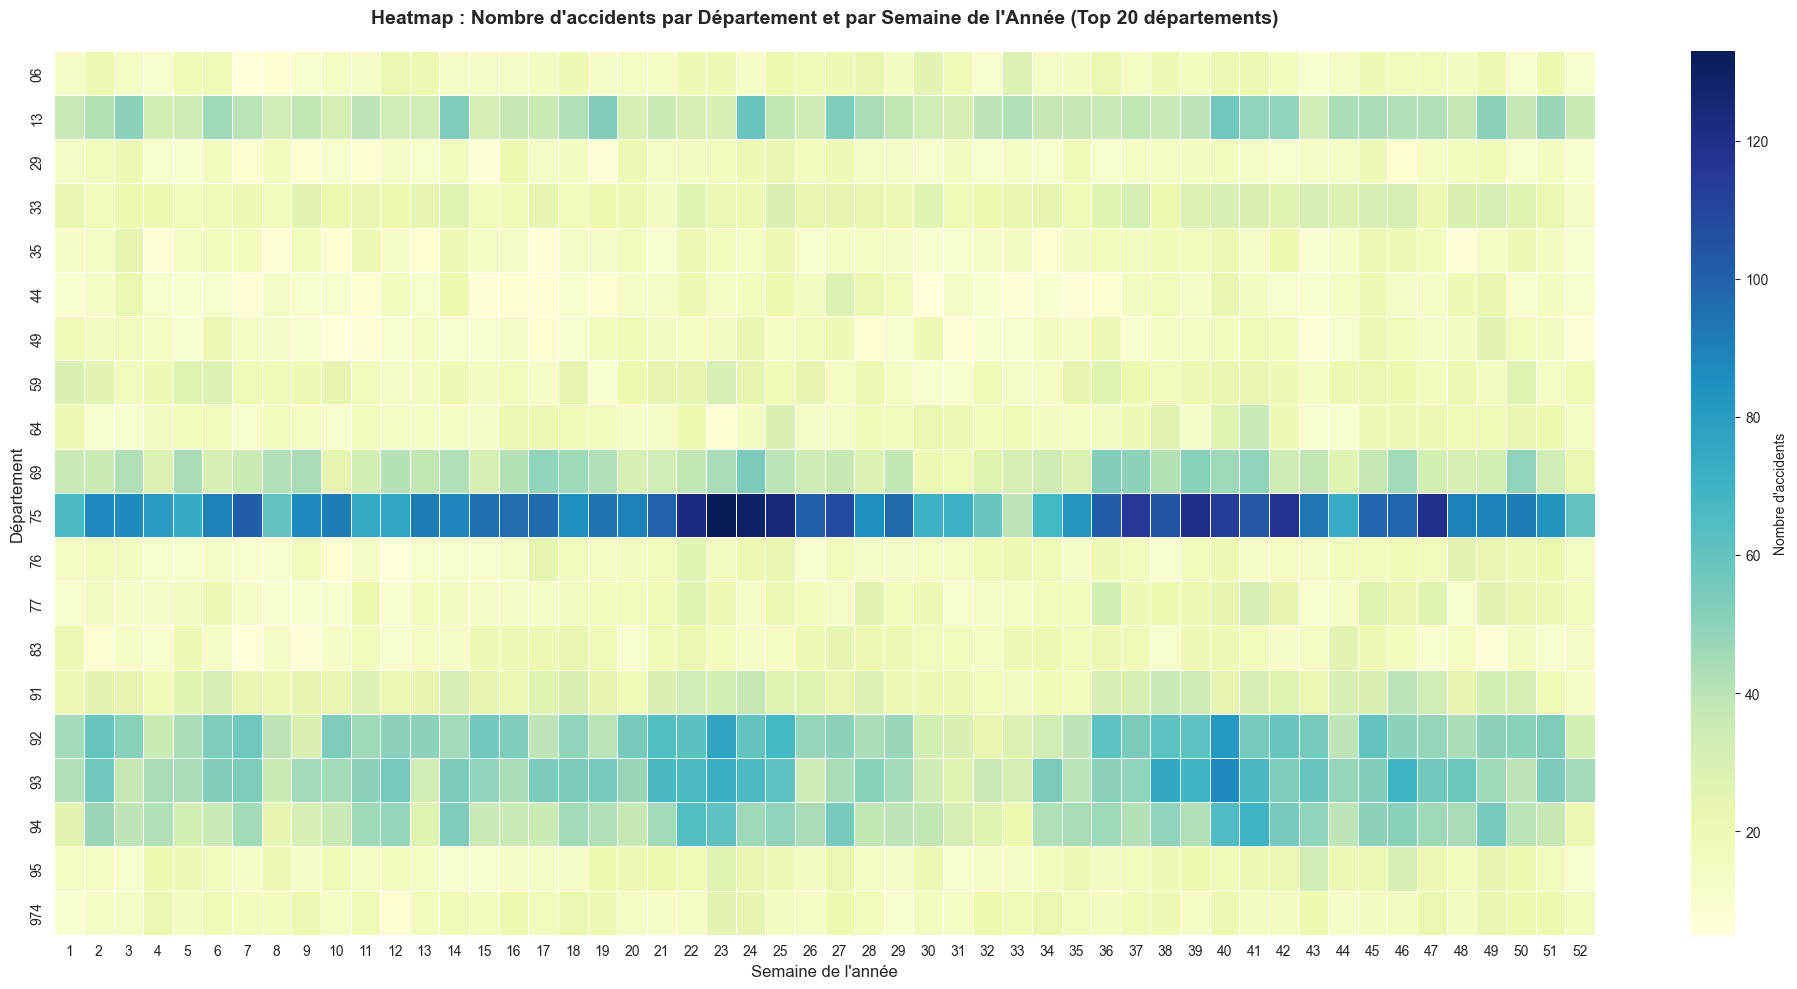

In [11]:
# ============================================================================
# ANALYSE BIVARIÉE 9 : ACCIDENTS PAR DÉPARTEMENT ET PAR SEMAINE DE L'ANNÉE
# ============================================================================

# Visualisation : Heatmap Département x Semaine (Top 20 départements)
pivot_semaine = pd.crosstab(df_top_dep['dep'], df_top_dep['semaine_annee'])

plt.figure(figsize=(20, 10))
sns.heatmap(pivot_semaine, annot=False, cmap='YlGnBu', 
            cbar_kws={'label': 'Nombre d\'accidents'}, linewidths=0.5)
plt.title('Heatmap : Nombre d\'accidents par Département et par Semaine de l\'Année (Top 20 départements)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Semaine de l\'année', fontsize=12)
plt.ylabel('Département', fontsize=12)
plt.tight_layout()
plt.show()


In [12]:
# ============================================================================
# ANALYSE BIVARIÉE 10 : RÉSUMÉ ET CONCLUSIONS
# ============================================================================

print("="*80)
print("RÉSUMÉ DE L'ANALYSE BIVARIÉE : DATETIME vs DÉPARTEMENT")
print("="*80)

print(f"\n1. Données analysées :")
print(f"   - Nombre total d'accidents : {len(df_clean):,}")
print(f"   - Nombre de départements : {df_clean['dep'].nunique()}")
print(f"   - Période couverte : {df_clean['date'].min().strftime('%d/%m/%Y')} au {df_clean['date'].max().strftime('%d/%m/%Y')}")

print(f"\n2. Top 10 départements par nombre d'accidents :")
top_10_summary = df_clean['dep'].value_counts().head(10)
for i, (dep, count) in enumerate(top_10_summary.items(), 1):
    pct = (count / len(df_clean) * 100)
    print(f"   {i:2d}. Département {dep:>3s} : {count:>6,} accidents ({pct:>5.2f}%)")

print(f"\n3. Répartition temporelle globale :")
print(f"   - Heure moyenne : {df_clean['heure'].mean():.2f}h")
print(f"   - Jour le plus fréquent : {df_clean['jour_semaine_fr'].mode()[0]}")
print(f"   - Mois le plus fréquent : {df_clean['mois_nom'].mode()[0]}")

print(f"\n4. Analyses réalisées :")
print(f"   ✓ Accidents par département et par mois")
print(f"   ✓ Accidents par département et par jour de la semaine")
print(f"   ✓ Accidents par département et par heure")
print(f"   ✓ Accidents par département et par période de la journée")
print(f"   ✓ Séries temporelles par département")
print(f"   ✓ Profils temporels normalisés par département")
print(f"   ✓ Accidents par département et par semaine de l'année")

print("\n" + "="*80)


RÉSUMÉ DE L'ANALYSE BIVARIÉE : DATETIME vs DÉPARTEMENT

1. Données analysées :
   - Nombre total d'accidents : 54,822
   - Nombre de départements : 107
   - Période couverte : 01/01/2023 au 31/12/2023

2. Top 10 départements par nombre d'accidents :
    1. Département  75 :  4,763 accidents ( 8.69%)
    2. Département  93 :  2,650 accidents ( 4.83%)
    3. Département  92 :  2,563 accidents ( 4.68%)
    4. Département  94 :  2,204 accidents ( 4.02%)
    5. Département  13 :  2,057 accidents ( 3.75%)
    6. Département  69 :  1,921 accidents ( 3.50%)
    7. Département  91 :  1,319 accidents ( 2.41%)
    8. Département  33 :  1,189 accidents ( 2.17%)
    9. Département  59 :  1,004 accidents ( 1.83%)
   10. Département  95 :    906 accidents ( 1.65%)

3. Répartition temporelle globale :
   - Heure moyenne : 13.38h
   - Jour le plus fréquent : Vendredi
   - Mois le plus fréquent : Juin

4. Analyses réalisées :
   ✓ Accidents par département et par mois
   ✓ Accidents par département et p